In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))

# I/O
io$output.directory <- file.path(io$basedir,"ArchR")
dir.create(file.path(io$output.directory), showWarnings = FALSE)

setwd(io$output.directory)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
       

In [5]:
max(ArchRProject@cellColData$DoubletEnrichment)

[1] 32.83333

In [1]:
source(here::here("settings.R"))
genomeAnnotation = readRDS(file.path(io$basedir, 'genomeAnnotation.rds'))
geneAnnotation = readRDS(file.path(io$basedir, 'geneAnnotation.rds'))

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE



In [28]:
geneAnnotation$genes[grep('ENSOCUG00000004859', geneAnnotation$genes$gene_id)]

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id      symbol
         <Rle>         <IRanges>  <Rle> |        <character> <character>
  [1]    chr21 15366557-15430129      - | ENSOCUG00000004859       RNFT2
  -------
  seqinfo: 22 sequences from an unspecified genome

In [34]:
ensoc_genes = geneAnnotation$genes[grep('ENSOCUG', geneAnnotation$genes$symbol)]$gene_id

In [35]:
write.csv(ensoc_genes, '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/genome/10x_rabbit_ref/ensoc_genes.csv')

In [12]:
genomeAnnotation$chromSizes

GRanges object with 22 ranges and 0 metadata columns:
       seqnames      ranges strand
          <Rle>   <IRanges>  <Rle>
   [1]     chr1 1-194850757      *
   [2]    chr10  1-47997241      *
   [3]    chr11  1-87554214      *
   [4]    chr12 1-155355395      *
   [5]    chr13 1-143360832      *
   ...      ...         ...    ...
  [18]     chr6  1-27502587      *
  [19]     chr7 1-173684459      *
  [20]     chr8 1-111795807      *
  [21]     chr9 1-116251907      *
  [22]     chrX 1-111700775      *
  -------
  seqinfo: 22 sequences from an unspecified genome

In [36]:
geneAnnotation$genes
geneAnnotation$TSS

GRanges object with 21102 ranges and 2 metadata columns:
          seqnames              ranges strand |            gene_id
             <Rle>           <IRanges>  <Rle> |        <character>
      [1]     chr1         15188-30378      + | ENSOCUG00000014251
      [2]     chr1         52453-53037      + | ENSOCUG00000005054
      [3]     chr1         57421-74905      - | ENSOCUG00000005046
      [4]     chr1         75200-85748      + | ENSOCUG00000005044
      [5]     chr1         92423-95845      - | ENSOCUG00000005040
      ...      ...                 ...    ... .                ...
  [21098]     chrX 111491397-111496239      - | ENSOCUG00000007220
  [21099]     chrX 111494764-111494835      - | ENSOCUG00000019315
  [21100]     chrX 111523844-111597291      + | ENSOCUG00000029751
  [21101]     chrX 111532709-111532815      - | ENSOCUG00000022547
  [21102]     chrX 111628200-111629717      - | ENSOCUG00000027130
                      symbol
                 <character>
      [1]     

GRanges object with 38003 ranges and 2 metadata columns:
                     seqnames    ranges strand |     tx_id            tx_name
                        <Rle> <IRanges>  <Rle> | <integer>        <character>
  ENSOCUG00000014251     chr1     15188      + |         1 ENSOCUT00000014253
  ENSOCUG00000014251     chr1     20324      + |         2 ENSOCUT00000038745
  ENSOCUG00000005054     chr1     52453      + |         3 ENSOCUT00000005053
  ENSOCUG00000005044     chr1     75200      + |         4 ENSOCUT00000005041
  ENSOCUG00000005028     chr1    125890      + |         5 ENSOCUT00000005032
                 ...      ...       ...    ... .       ...                ...
  ENSOCUG00000000255     chrX 111369675      - |     37999 ENSOCUT00000000255
  ENSOCUG00000007220     chrX 111496239      - |     38000 ENSOCUT00000007220
  ENSOCUG00000019315     chrX 111494835      - |     38001 ENSOCUT00000019315
  ENSOCUG00000022547     chrX 111532815      - |     38002 ENSOCUT00000023399
  ENSOC

In [3]:
matrix = 'TileMatrix'

In [8]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))

    #### Read RNA ####
    io$RNA_in <- file.path(io$basedir,"RNA/RangedSummarizedExperiment.rds")
    sceRNA = readRDS(io$RNA_in)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE



In [9]:
sceRNA

class: RangedSummarizedExperiment 
dim: 20845 146133 
metadata(0):
assays(1): counts
rownames: NULL
rowData names(0):
colnames(146133): cell_1 cell_2 ... cell_172994 cell_172995
colData names(3): cell celltype stage

In [7]:
rowData(sceRNA)

DataFrame with 20845 rows and 2 columns
                              gene_id             symbol
                          <character>        <character>
WDR31              ENSOCUG00000014251              WDR31
RNF183             ENSOCUG00000005054             RNF183
PRPF4              ENSOCUG00000005046              PRPF4
CDC26              ENSOCUG00000005044              CDC26
SLC31A1            ENSOCUG00000005040            SLC31A1
...                               ...                ...
U4                 ENSOCUG00000018898                 U4
U4                 ENSOCUG00000021769                 U4
ENSOCUG00000036949 ENSOCUG00000036949 ENSOCUG00000036949
ENSOCUG00000014718 ENSOCUG00000014718 ENSOCUG00000014718
ENSOCUG00000019471 ENSOCUG00000019471 ENSOCUG00000019471

In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))

geneAnnotation = readRDS(file.path(io$basedir, 'geneAnnotation.rds'))

geneAnnotation

rna_in = '/rds/project/rds-SDzz0CATGms/users/mlnt2/PhD_MT06/'
rna_out = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/RNA/'
counts_in = file.path(rna_in, '3_cellqc/raw_counts.mtx')
genes_in = file.path(rna_in, '2_cellcalling/genes.tsv')
meta_in1 = file.path(rna_in, '5_doublet/meta.tab')
meta_in2 = file.path('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/metadata.csv')
sizefactors_in = file.path(rna_in, 'sizefactors.tab')

dir.create(file.path(rna_out), showWarnings = FALSE)


# Load data
counts = readMM(counts_in)
genes = fread(genes_in, header=FALSE)
meta = fread(meta_in1)

# Change col & row names
colnames(counts) = meta$cell
rownames(counts) = genes$V1

# Keep only cells that are not doublet or stripped nuclei
keep = meta[meta$doublet==FALSE & meta$stripped==FALSE,]$cell
counts = counts[,keep]





here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE



List of length 3
names(3): genes exons TSS

ERROR: Error in fread(paste0(rna_out, "annotations_final.tsv")): File '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/RNA/annotations_final.tsv' does not exist or is non-readable. getwd()=='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR'


In [5]:
# load new metadata
celltypes = fread(paste0(rna_out, 'annotations_final.tsv')) %>%
     setnames(c('V1', 'assigned_celltype'), c('cell', 'celltype')) %>%
    .[order(match(cell, colnames(counts))),]
stages = fread(paste0(rna_out, 'metadata.csv')) %>%
    setnames('index', 'cell') %>%
     .[,c('cell', 'stage')] %>%
     .[order(match(cell, colnames(counts))),] 
meta = cbind(celltypes, stages[,2])

# Extract Granges of genes
rowranges = geneAnnotation$genes
genes_keep = genes[genes$V1 %in% rowranges$gene_id,]$V1 # keep only genes in ATAC data
counts = counts[genes_keep, ] 
rowranges = rowranges[rowranges$gene_id %in% rownames(counts),]
rowranges = rowranges[order(match(rowranges$gene_id, rownames(counts))),] # Match order between RNA & ATAC (not needed?)

# Create Ranged SummarizedExperiment object of scRNA-seq data
sceRNA <- SummarizedExperiment(assays=SimpleList(counts=counts),rowRanges=rowranges, colData=meta)
rownames(sceRNA) = sceRNA@rowRanges$symbol

Warning message in fread(paste0(rna_out, "annotations_final.tsv")):
“Detected 1 column names but the data has 2 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


In [6]:
sceRNA

class: RangedSummarizedExperiment 
dim: 20845 146133 
metadata(0):
assays(1): counts
rownames(20845): WDR31 RNF183 ... ENSOCUG00000014718 ENSOCUG00000019471
rowData names(2): gene_id symbol
colnames(146133): cell_1 cell_2 ... cell_172994 cell_172995
colData names(3): cell celltype stage

In [7]:

# Save object
saveRDS(sceRNA, file.path(rna_out, 'RangedSummarizedExperiment.rds'))

### bigwigs

In [2]:
addArchRThreads(12)

Setting default number of Parallel threads to 12.



In [5]:
library(parallel)

In [3]:
ArchRProject@cellColData$celltype_manual = gsub(" ", "_", ArchRProject@cellColData$celltype_manual)

In [12]:
ArchRProject = addBgdPeaks(
  ArchRProj = ArchRProject, force=TRUE)

Identifying Background Peaks!



In [14]:
ArchRProject <- addPeakMatrix(ArchRProject)

ArchR logging to : ArchRLogs/ArchR-addPeakMatrix-a7787589875a-Date-2022-01-24_Time-16-19-58.log
If there is an issue, please report to github with logFile!

2022-01-24 16:19:59 : Batch Execution w/ safelapply!, 0 mins elapsed.

Overriding previous entry for ReadsInPeaks

Overriding previous entry for FRIP

ArchR logging successful to : ArchRLogs/ArchR-addPeakMatrix-a7787589875a-Date-2022-01-24_Time-16-19-58.log



In [17]:
getGroupBW(
  ArchRProj = ArchRProject,
  groupBy = "sample",
  normMethod = "ReadsInTSS",
  tileSize = 100,
  maxCells = 1000,
  ceiling = 4,
  verbose = TRUE,
  threads = getArchRThreads(),
  logFile = createLogFile("getGroupBW")
)

ArchR logging to : ArchRLogs/ArchR-getGroupBW-a7784ede2308-Date-2022-01-24_Time-16-42-27.log
If there is an issue, please report to github with logFile!



In [18]:
ArchRProject = getGroupBW(
  ArchRProj = ArchRProject,
  groupBy = "celltype_manual",
  normMethod = "ReadsInTSS",
  tileSize = 100,
  maxCells = 1000,
  ceiling = 4,
  verbose = TRUE,
  threads = getArchRThreads(),
  logFile = createLogFile("getGroupBW")
)

ArchR logging to : ArchRLogs/ArchR-getGroupBW-a7786af046a3-Date-2022-01-24_Time-16-46-04.log
If there is an issue, please report to github with logFile!

2022-01-24 16:46:09 : Allantois (1 of 22) : Creating BigWig for Group, 0.083 mins elapsed.

Warning message in mclapply(..., mc.cores = threads, mc.preschedule = preschedule):
“1 function calls resulted in an error”


ERROR: Error in .safelapply(seq_along(availableChr), function(k) {: 
Error Found Iteration 16 : 
	[1] "Error in `[[<-`(`*tmp*`, name, value = c(6, 16, 14, 10, 9, 10, 11, 11,  : \n  913942 elements in value to replace 913941 elements\n"
	<simpleError in `[[<-`(`*tmp*`, name, value = c(6, 16, 14, 10, 9, 10, 11, 11, 3, 4, 3, 2, 2, 2, 3, 2, 4, 3, 0, 1, 6, 7, 6, 5, 8, 4, 3, 3, 0, 2, 0, 2, 1, 1, 0, 0, 0, 0, 2, 1, 1, 2, 0, 5, 5, 10, 3, 3, 3, 1, 6, 2, 3, 3, 1, 3, 0, 1, 1, 0, 0, 1, 4, 1, 1, 



In [20]:
# p <- ArgumentParser(description='')
# # p$add_argument('--sample',        type="character",                               help='input sample')
# # p$add_argument('--min_fragments',          type="integer",  default=2500,   help='Minimum fragments')
# # p$add_argument('--min_tss_score',       type="integer",  default=2,  help='Minimum TSS score')
# # p$add_argument('--outdir',          type="character",                               help='Output directory')

# args <- p$parse_args(commandArgs(TRUE))
args = list()
args$test = TRUE
if(args$test){
    args$sample = 'BGRGP1'
    args$min_fragments = 1000
    args$min_tss_score = 2
    args$outdir = io$output.directory
}

In [21]:
addArchRThreads(threads = 1) 

Setting default number of Parallel threads to 1.



In [24]:
#important as rabbit chromosome dont have the 'chr' prefix
addArchRChrPrefix(chrPrefix = FALSE)

genomeAnnotation = readRDS(file.path(io$basedir, 'genomeAnnotation.rds'))
geneAnnotation = readRDS(file.path(io$basedir, 'geneAnnotation.rds'))

ArchR is now disabling the requirement of chromosome prefix = 'chr'



In [25]:
fragment_file_path = "/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/data/BGRGP1_fragments.tsv.gz"

In [26]:
#Create Arrow File
ArrowFiles <- createArrowFiles(
  inputFiles = fragment_file_path,
  sampleNames = paste0('rabbit_', args$sample),
    
  minTSS = args$min_tss_score, #Dont set this too high because you can always increase later
  minFrags = args$min_fragments , 
    
  addTileMat = TRUE,
  addGeneScoreMat = TRUE,
    
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)


# Calculate doublet scores

ArrowFile = paste0(io$output.directory, '/rabbit_', args$sample, '.arrow')

doubScores <- addDoubletScores(
  input = ArrowFiles[1],
  k = 15, #Refers to how many cells near a "pseudo-doublet" to count.
  knnMethod = "UMAP", #Refers to the embedding to use for nearest neighbor search.
  LSIMethod = 1
)

ArchR logging to : ArchRLogs/ArchR-createArrows-16d1c5d10485a-Date-2022-01-06_Time-09-53-53.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

2022-01-06 09:53:53 : Batch Execution w/ safelapply!, 0 mins elapsed.

(rabbit_BGRGP1 : 1 of 1) Checking if completed file exists!

2022-01-06 09:53:53 : (rabbit_BGRGP1 : 1 of 1) Arrow Exists! Overriding since not completed!, 0.001 mins elapsed.

(rabbit_BGRGP1 : 1 of 1) Determining Arrow Method to use!

2022-01-06 09:53:53 : (rabbit_BGRGP1 : 1 of 1) Reading In Fragments from inputFiles (readMethod = tabix), 0.001 mins elapsed.

2022-01-06 09:53:53 : (rabbit_BGRGP1 : 1 of 1) Tabix Bed To Temporary File, 0.001 mins elapsed.

(rabbit_BGRGP1 : 1 of 1) found fragments when removed chromosome prefix : chr1:1-38970151

(rabbit_BGRGP1 : 1 of 1) found fragments when removed chromosome prefix : chr1:38970152-77940302

(rabbit_BGRGP1 : 1 of 1) found fragments when removed chromosome prefix : chr1:77940303-116910454


(rabbit_BGRGP1 : 1 of 1) found fragments when removed chromosome prefix : chr20:13276533-19914799

(rabbit_BGRGP1 : 1 of 1) found fragments when removed chromosome prefix : chr20:19914800-26553065

(rabbit_BGRGP1 : 1 of 1) found fragments when removed chromosome prefix : chr20:26553066-33191332

(rabbit_BGRGP1 : 1 of 1) found fragments when removed chromosome prefix : chr21:1-3115655

(rabbit_BGRGP1 : 1 of 1) found fragments when removed chromosome prefix : chr21:3115656-6231310

(rabbit_BGRGP1 : 1 of 1) found fragments when removed chromosome prefix : chr21:6231311-9346965

(rabbit_BGRGP1 : 1 of 1) found fragments when removed chromosome prefix : chr21:9346966-12462620

Warning message in sprintf("%s Reading TabixFile %s Percent", prefix, round(100 * :
“one argument not used by format '%s Reading TabixFile %s Percent'”
2022-01-06 10:11:30 : (rabbit_BGRGP1 : 1 of 1) Reading TabixFile 64 Percent, 17.615 mins elapsed.

(rabbit_BGRGP1 : 1 of 1) found fragments when removed chromosome pref

Warning message in valid.GenomicRanges.seqinfo(x, suggest.trim = TRUE):
“GRanges object contains 3 out-of-bound ranges located on sequences
  chr12, chr13, and chr16. Note that ranges located on a sequence whose
  length is unknown (NA) or on a circular sequence are not considered
  out-of-bound (use seqlengths() and isCircular() to get the lengths and
  circularity flags of the underlying sequences). You can use trim() to
  trim these ranges. See ?`trim,GenomicRanges-method` for more
  information.”
2022-01-06 10:31:23 : (rabbit_BGRGP1 : 1 of 1) Removing Fragments from Filtered Cells, 37.504 mins elapsed.

2022-01-06 10:31:23 : (rabbit_BGRGP1 : 1 of 1) Creating Filtered Arrow File, 37.504 mins elapsed.

2022-01-06 10:32:55 : (rabbit_BGRGP1 : 1 of 1) Finished Constructing Filtered Arrow File!, 39.03 mins elapsed.

2022-01-06 10:32:55 : (rabbit_BGRGP1 : 1 of 1) Adding TileMatrix!, 39.032 mins elapsed.

2022-01-06 10:36:26 : (rabbit_BGRGP1 : 1 of 1) Adding GeneScoreMatrix!, 42.55 mins el

# QC

In [115]:
here::i_am("snakemake/01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))

# I/O
io$output.directory <- file.path(io$basedir,"ArchR")
setwd(io$output.directory)
io$outdir <- file.path(io$output.directory,"qc")
dir.create(file.path(io$outdir), showWarnings = FALSE)

######################
## Define arguments ##
######################
# p <- ArgumentParser(description='')
# p$add_argument('--min_log_nFrags',          type="integer",  default=12,   help='Minimum fragments')
# p$add_argument('--min_tss_score',       type="integer",  default=2,  help='Minimum TSS score')
# args <- p$parse_args(commandArgs(TRUE))
args = list()
args$test = TRUE
if(args$test){
args$min_log_nFrags = 12
args$min_tss_score = 2
}

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-' 

In [116]:
# Create metadata
archR_metadata <- getCellColData(ArchRProject) %>%
  as.data.table(keep.rownames = T) %>% setnames("rn","cell") %>%
  .[,c("cell", "TSSEnrichment", "ReadsInTSS", "PromoterRatio", "NucleosomeRatio", "nFrags")] %>%
   .[,sample:=strsplit(cell,"#") %>% map_chr(1)]

 stages = data.frame('sample' = c('rabbit_BGRGP1', 'rabbit_BGRGP2', 'rabbit_BGRGP3', 'rabbit_BGRGP4', 'rabbit_BGRGP5', 'rabbit_BGRGP6', 'rabbit_BGRGP7', 'rabbit_BGRGP8'),
                     'stage' = c('GD7', 'GD8', 'GD8', 'GD9_ExE', 'GD9', 'GD9', 'GD9', 'GD9' ))

 archR_metadata = merge(archR_metadata, stages, by='sample')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [117]:
metadata.to.archR <- archR_metadata %>% 
  .[cell%in%rownames(archRProject)] %>% setkey(cell) %>% .[rownames(archRProject)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")

stopifnot(all(metadata.to.archR$TSSEnrichment_atac == getCellColData(archRProject, "TSSEnrichment")[[1]]))

for (i in colnames(metadata.to.archR)) {
  archRProject <- addCellColData(
    archRProject,
    data = metadata.to.archR[[i]], 
    name = i,
    cells = rownames(metadata.to.archR),
    force = TRUE
  )
}

fwrite(archR_metadata, file.path(io$output.directory, 'metadata.txt.gz'), sep="\t", na="NA", quote=F)
#saveArchRProject(archRProject)

Overriding previous entry for sample

Overriding previous entry for TSSEnrichment

Overriding previous entry for ReadsInTSS

Overriding previous entry for PromoterRatio

Overriding previous entry for NucleosomeRatio

Overriding previous entry for nFrags



In [118]:
########################
## Load cell metadata ##
########################
io$metadata <- file.path(io$output.directory, 'metadata.txt.gz')
sample_metadata <- fread(io$metadata)

#############
## Call QC ##
#############

sample_metadata %>%
    .[,pass_atacQC:=TSSEnrichment>=args$min_tss_score & log2(nFrags)>=args$min_log_nFrags] %>%
    .[is.na(pass_atacQC),pass_atacQC:=FALSE]

fwrite(sample_metadata, file.path(io$output.directory, 'metadata_qc.txt.gz'), sep="\t", na="NA", quote=F)


In [119]:
##################
## Subset ArchR ##
##################

if (args$test) {
  
  # Subset cells for faster computations
  cells.to.use <- split(ArchRProject$cellNames,as.vector(ArchRProject@cellColData$Sample)) %>% map(~ head(.,n=1000)) %>% unlist
  
  # Subset features for faster computations
  tss.granges <- getTSS(ArchRProject)
  tss.granges <- tss.granges[seqnames(tss.granges)%in%c("chr1","chr2","chr3")]
  ArchRProject <- ArchRProject[cells.to.use,]
}

In [120]:

tss.granges <- getTSS(ArchRProject)
if (args$test) tss.granges <- tss.granges[seqnames(tss.granges)%in%c("chr1","chr2","chr3")]

to.plot.tss <- opts$samples %>% map(function(i) {
  plotTSSEnrichment(
    ArchRProj = ArchRProject[ArchRProject$Sample==i,], 
    groupBy = "Sample", 
    returnDF = TRUE,
    TSS = tss.granges
  ) %>% as.data.table %>% return
}) %>% rbindlist %>% 
  setnames("group","sample") %>% 
  melt(id.vars=c("sample","x"))

ArchR logging to : ArchRLogs/ArchR-plotTSSEnrichment-16d1c2eea7048-Date-2022-01-06_Time-11-29-36.log
If there is an issue, please report to github with logFile!

2022-01-06 11:29:37 : rabbit_BGRGP1 Computing TSS (1 of 1)!, 0.006 mins elapsed.

2022-01-06 11:29:56 : rabbit_BGRGP1 Finished Computing TSS (1 of 1)!, 0.323 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotTSSEnrichment-16d1c2eea7048-Date-2022-01-06_Time-11-29-36.log

ArchR logging to : ArchRLogs/ArchR-plotTSSEnrichment-16d1ce3fd812-Date-2022-01-06_Time-11-29-56.log
If there is an issue, please report to github with logFile!

2022-01-06 11:29:56 : rabbit_BGRGP2 Computing TSS (1 of 1)!, 0.008 mins elapsed.

2022-01-06 11:30:16 : rabbit_BGRGP2 Finished Computing TSS (1 of 1)!, 0.341 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotTSSEnrichment-16d1ce3fd812-Date-2022-01-06_Time-11-29-56.log

Warning message in melt.data.table(., id.vars = c("sample", "x")):
“'measure.vars' [value, normValue, smoo

In [121]:

# For some reason this doesnt work........
fwrite(to.plot.tss, sprintf("%s/qc_TSSenrichment.txt.gz",io$outdir))

to.plot.tss <- fread(sprintf("%s/qc_TSSenrichment.txt.gz",io$outdir)) %>% 
  merge(unique(sample_metadata[,c("stage","sample")]),by="sample") %>%
  .[,.(value=mean(value)), by = c("stage","x","variable")]

p <- ggline(to.plot.tss[variable=="normValue"], x="x", y="value", plot_type="l", color="stage") +
  facet_wrap(~stage, scales="fixed", nrow=1) +
  labs(x="Distance from TSS (bp)", y="TSS enrichment (normalised)") +
  theme(
    axis.text = element_text(size=rel(0.5)),
    axis.title = element_text(size=rel(0.75)),
    legend.position = "none",
    legend.title = element_blank()
  )

pdf(sprintf("%s/qc_TSSenrichment.pdf",io$outdir), width=8, height=4)
print(p)
dev.off()

#####################################
## Plot Fragment size distribution ##
#####################################

to.plot.fragmentsize <- plotFragmentSizes(ArchRProject, groupBy = "Sample", returnDF=T) %>% 
  as.data.table %>% setnames("group","sample")
fwrite(to.plot.fragmentsize, sprintf("%s/qc_FragmentSizeDistribution.txt.gz",io$outdir))

to.plot.fragmentsize <- fread(sprintf("%s/qc_FragmentSizeDistribution.txt.gz",io$outdir)) %>% 
  merge(unique(sample_metadata[,c("stage","sample")]),by="sample") %>%
  .[,.(fragmentPercent=mean(fragmentPercent)), by = c("stage","fragmentSize")]

p <- ggline(to.plot.fragmentsize, x="fragmentSize", y="fragmentPercent", plot_type="l", color="stage") +
  facet_wrap(~stage, scales="fixed", nrow=1) +
  scale_x_continuous(breaks=seq(125,750,125)) +
  labs(x="Fragment Size (bp)", y="Percentage of fragments (%)") +
  theme(
    axis.text = element_text(size=rel(0.55)),
    axis.title = element_text(size=rel(0.75)),
    legend.position = "right",
    legend.title = element_blank()
  )

pdf(sprintf("%s/qc_FragmentSizeDistribution.pdf",io$outdir), width=8, height=4)
print(p)
dev.off()

###########################################
## Plot summary statistics of QC metrics ##
###########################################

# Histograms

to.plot <- sample_metadata %>%
  .[!is.na(nFrags)] %>%
  .[,log_nFrags:=log10(nFrags)] %>%
  melt(id.vars=c("sample","cell"), measure.vars=c("TSSEnrichment","log_nFrags"))

tmp <- data.table(
  variable = c("TSSEnrichment", "log_nFrags"),
  value = c(args$min_tss_score, args$min_log_nFrags)
)
# p <- gghistogram(to.plot, x="value", fill="sample", bins=50) +
p <- gghistogram(to.plot, x="value", y="..density..", bins=70) +
  geom_vline(aes(xintercept=value), linetype="dashed", data=tmp) +
  facet_wrap(~variable, scales="free") +
  theme(
    axis.text =  element_text(size=rel(0.8)),
    axis.title.x = element_blank(),
    legend.position = "right",
    legend.text = element_text(size=rel(0.5))
  )
pdf(sprintf("%s/qc_metrics_histogram2.pdf",io$outdir), width=8, height=5)
print(p)
dev.off()



to.plot <- sample_metadata %>%
  .[pass_atacQC==TRUE & TSSEnrichment<21] %>%
  .[TSSEnrichment<21] %>%
  .[,log_nFrags:=log10(nFrags)] %>%
  melt(id.vars=c("sample","cell","stage"), measure.vars=c("TSSEnrichment","log_nFrags"))

# Boxplots
p <- ggboxplot(to.plot, x="sample", y="value", fill="stage", outlier.shape=NA) +
  facet_wrap(~variable, scales="free_y") +
  theme(
    # legend.position = "none",
    legend.title = element_blank(),
    axis.text.x = element_text(colour="black",size=rel(0.65)),  
    axis.text.y = element_text(colour="black",size=rel(0.75)),  
    axis.title.x = element_blank()
  )
pdf(sprintf("%s/qc_metrics_boxplot.pdf",io$outdir), width=10, height=6)
print(p)
dev.off()


#########################################################
## Plot fraction of cells that pass QC for each sample ##
#########################################################

to.plot <- sample_metadata %>%
  .[,mean(pass_atacQC),by="sample"]

p <- ggbarplot(to.plot, x="sample", y="V1", fill="gray70") +
    labs(x="", y="Fraction of cells that pass QC") +
  coord_cartesian(ylim=c(0,1)) +
    theme(
        axis.text.x = element_text(colour="black",size=rel(0.65), angle=20, hjust=1, vjust=1),  
    )

pdf(sprintf("%s/qc_metrics_barplot.pdf",io$outdir))
print(p)
dev.off()


png 
  2

ArchR logging to : ArchRLogs/ArchR-plotFragmentSizes-16d1c30330746-Date-2022-01-06_Time-11-30-17.log
If there is an issue, please report to github with logFile!

2022-01-06 11:30:17 : rabbit_BGRGP1 Computing FragmentSizes (1 of 2)!, 0.008 mins elapsed.

2022-01-06 11:31:03 : rabbit_BGRGP1 Finished Computing FragmentSizes (1 of 2)!, 0.781 mins elapsed.

2022-01-06 11:31:03 : rabbit_BGRGP2 Computing FragmentSizes (2 of 2)!, 0.781 mins elapsed.

2022-01-06 11:31:53 : rabbit_BGRGP2 Finished Computing FragmentSizes (2 of 2)!, 1.613 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotFragmentSizes-16d1c30330746-Date-2022-01-06_Time-11-30-17.log



png 
  2

png 
  2

png 
  2

png 
  2

# RNA Integration

In [4]:
here::i_am("snakemake/01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))

######################
## Define arguments ##
######################
p <- ArgumentParser(description='')
p$add_argument('--Matrix',          type="character",  default='TileMatrix',   help='Which Matrix to use')
args <- p$parse_known_args(commandArgs(TRUE))

args$Matrix = 'TileMatrix'

# I/O
io$output.directory <- file.path(io$basedir,"ArchR")
io$RNA_in <- file.path(io$basedir,"RNA/RangedSummarizedExperiment.rds")
setwd(io$output.directory)
io$outdir <- file.path(io$output.directory,"qc")
dir.create(file.path(io$outdir), showWarnings = FALSE)


#### Read RNA ####
sceRNA = readRDS(io$RNA_in)

#### Prepare for mapping ######
# Add metadata stage column where GD9_ExE = GD9
ArchRProject@cellColData$cell = rownames(ArchRProject@cellColData)
cells = rownames(ArchRProject@cellColData)
stages = data.frame('sample' = c('rabbit_BGRGP1', 'rabbit_BGRGP2', 'rabbit_BGRGP3', 'rabbit_BGRGP4', 'rabbit_BGRGP5', 'rabbit_BGRGP6', 'rabbit_BGRGP7', 'rabbit_BGRGP8'),
                    'stage_mapping' = c('GD7', 'GD8', 'GD8', 'GD9', 'GD9', 'GD9', 'GD9', 'GD9' ))
ArchRProject@cellColData = merge(ArchRProject@cellColData, stages, by='sample')

ArchRProject@cellColData = ArchRProject@cellColData[order(ArchRProject@cellColData$cell, cells),]
rownames(ArchRProject@cellColData) = ArchRProject@cellColData$cell

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-' 

In [6]:
stage_select = 'GD8'

In [7]:
    # Subset RNA
   # RNA_stage = subset(x = sceRNA, subset = stage == stage_select) # for seurat object
    RNA_stage = sceRNA[,colData(sceRNA)$stage == stage_select] # for RangedSummarizedExperiment object
    message(stage_select)
    # Subset ATAC 
    keep = rownames(ArchRProject@cellColData[ArchRProject@cellColData$stage_mapping==stage_select,])
    ATAC_stage = ArchRProject[keep]
    
    # ATAC dim redu
    # Iterative LSI: two iterations
    ATAC_stage <- addIterativeLSI(
      ArchRProj = ATAC_stage,
      useMatrix = args$Matrix, 
      name = "IterativeLSI", 
      firstSelection = "Top",
      depthCol = "nFrags",
      iterations = 2, 
      saveIterations = FALSE,
      varFeatures = 15000, 
      force = TRUE
    )
    
    # Add clusters
    ATAC_stage <- addClusters(input = ATAC_stage,  
                                     reducedDims = "IterativeLSI",
                                     resolution = 1.2, 
                                     force=TRUE)
    clusters = paste0(stage_select, '_', getCellColData(ATAC_stage)$Clusters)
    
    # Add imputation 
    ATAC_stage <- addImputeWeights(ATAC_stage)
    
    # Integrate
    ATAC_stage <- addGeneIntegrationMatrix(
        ArchRProj = ATAC_stage, 
        useMatrix = "GeneScoreMatrix",
        matrixName = paste0("GeneIntegrationMatrix_", args$Matrix),
        reducedDims = "IterativeLSI",
        seRNA = RNA_stage,
        addToArrow = TRUE,
        force= TRUE,
        groupRNA = "celltype",
        nameCell = "predictedCell_Un",
        nameGroup = "predictedGroup_celltype",
        nameScore = "predictedScore_celltype")
    
    # Extract mapping
    meta = as.data.frame(ATAC_stage@cellColData[, c('predictedCell_Un', 'predictedGroup_celltype', 'predictedScore_celltype')])
    meta$stage_clusters = clusters
    meta$cell = rownames(meta)

GD8

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-7789540be7fb-Date-2022-01-08_Time-12-07-26.log
If there is an issue, please report to github with logFile!

2022-01-08 12:07:27 : Computing Total Across All Features, 0.013 mins elapsed.

2022-01-08 12:07:28 : Computing Top Features, 0.031 mins elapsed.

###########
2022-01-08 12:07:29 : Running LSI (1 of 2) on Top Features, 0.048 mins elapsed.
###########

2022-01-08 12:07:29 : Creating Partial Matrix, 0.048 mins elapsed.

2022-01-08 12:07:56 : Computing LSI, 0.494 mins elapsed.

2022-01-08 12:08:07 : Identifying Clusters, 0.671 mins elapsed.

Warning message:
“package ‘Seurat’ was built under R version 4.1.2”
2022-01-08 12:08:18 : Identified 6 Clusters, 0.85 mins elapsed.

2022-01-08 12:08:18 : Creating Cluster Matrix on the total Group Features, 0.851 mins elapsed.

2022-01-08 12:09:22 : Computing Variable Features, 1.931 mins elapsed.

###########
2022-01-08 12:09:23 : Running LSI (2 of 2) on Variable Featu

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 6546
Number of edges: 382182

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8368
Number of communities: 17
Elapsed time: 0 seconds


2022-01-08 12:10:04 : Testing Outlier Clusters, 0.142 mins elapsed.

2022-01-08 12:10:04 : Assigning Cluster Names to 17 Clusters, 0.142 mins elapsed.

2022-01-08 12:10:04 : Finished addClusters, 0.143 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-77895301993f-Date-2022-01-08_Time-12-10-04.log
If there is an issue, please report to github with logFile!

2022-01-08 12:10:04 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.

Warning message in sprintf("Completed Getting Magic Weights!", round(object.size(weightList)/10^9, :
“one argument not used by format 'Completed Getting Magic Weights!'”
ArchR logging to : ArchRLogs/ArchR-addGeneIntegrationMatrix-77893015026b-Date-2022-01-08_Time-12-10-13.log
If there is an issue, please report to github with logFile!

2022-01-08 12:10:13 : Running Seurat's Integration Stuart* et al 2019, 0.003 mins elapsed.

2022-01-08 12:10:16 : Checking ATAC Input, 0.047 mins elapsed.

2022-01-08 12:10:16 : Checking RNA Input

In [8]:
head(meta)

,predictedCell_Un,predictedGroup_celltype,predictedScore_celltype,stage_clusters,cell
,<chr>,<chr>,<dbl>,<chr>,<chr>
rabbit_BGRGP2#AAACGAAAGAACCCGA-1,cell_29699,SCT,1.0000000,GD8_C4,rabbit_BGRGP2#AAACGAAAGAACCCGA-1
rabbit_BGRGP2#AAACGAAAGACTTCCA-1,cell_21193,Early Erythrocytes,0.5705596,GD8_C14,rabbit_BGRGP2#AAACGAAAGACTTCCA-1
rabbit_BGRGP2#AAACGAAAGCGCATTT-1,cell_18597,EXE mesoderm,0.4727057,GD8_C10,rabbit_BGRGP2#AAACGAAAGCGCATTT-1
rabbit_BGRGP2#AAACGAAAGCGTAGCA-1,cell_19729,Early Erythrocytes,0.5430140,GD8_C8,rabbit_BGRGP2#AAACGAAAGCGTAGCA-1
rabbit_BGRGP2#AAACGAACAAGTGGCA-1,cell_38950,SCT,0.6069618,GD8_C5,rabbit_BGRGP2#AAACGAACAAGTGGCA-1
rabbit_BGRGP2#AAACGAACAGCAACAG-1,cell_29813,Cardiomyocytes,0.2435041,GD8_C12,rabbit_BGRGP2#AAACGAACAGCAACAG-1


## Dim redu

In [166]:
here::i_am("snakemake/01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))

# I/O
io$output.directory <- file.path(io$basedir,"ArchR")
setwd(io$output.directory)
io$outdir <- file.path(io$output.directory,"dimensionality_reduction")
dir.create(file.path(io$outdir), showWarnings = FALSE)

######################
## Define arguments ##
######################
p <- ArgumentParser(description='')
    p$add_argument('--metadata',       type="character",                 help='Metadata filepath')
    p$add_argument('--nfeatures',       type="integer",    default=15000,               help='Number of features')
    p$add_argument('--matrix',          type="character",  default="TileMatrix",   help='Matrix to use')
    p$add_argument('--ndims',           type="integer",    default=30,                  help='Number of LSI dimensions')
    p$add_argument('--batch.variable',  type="character",                               help='Metadata column to apply batch correction on')
    p$add_argument('--batch.method',    type="character",  default="Harmony",               help='Batch correctin method ("Harmony" or "MNN")')
    p$add_argument('--n_neighbors',     type="integer",    default=30,   nargs='+',     help='(UMAP) Number of neighbours')
    p$add_argument('--min_dist',        type="double",     default=0.3,  nargs='+',     help='(UMAP) Minimum distance')
    p$add_argument('--colour_by',       type="character",  nargs='+',  help='Metadata columns to colour the UMAP by')
    p$add_argument('--seed',            type="integer",    default=42,                  help='Random seed')
    p$add_argument('--outdir',          type="character",                               help='Output directory')
    p$add_argument('--final_run',          type="integer",  default=0, help='Saves those parameters to ArchRProject')
args <- p$parse_known_args(commandArgs(TRUE))

args$test = TRUE
if(args$test){
## START TEST ##
 args <- list()
 args$metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR/metadata_qc.txt.gz"
 args$nfeatures <- 15000
 args$matrix <- "TileMatrix"
 args$batch.variable = "stage"
 args$batch.method = "Harmony"
 args$ndims <- 25
 args$seed <- 42
 args$n_neighbors <- c(25,35)
 args$min_dist <- c(0.3,0.6)
 args$colour_by <- c("sample","stage","cluster")
 args$vars_to_regress <- c("nFeature_RNA","mitochondrial_percent_RNA")
 args$outdir <- "/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR/dimensionality_reduction"
## END TEST ##
}

dir.create(args$outdir, showWarnings = FALSE)

# Options
opts$lsi.iterations = 2
opts$lsi.cluster.resolution = 2

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-' 

In [167]:
##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE] 

# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]


In [173]:
if(args$test){
    ArchRProject.filt = ArchRProject.filt[1:1000]
}

In [175]:
###########################
## Latent Semantic Index ##
###########################

# Iterative LSI: two iterations
ArchRProject.filt <- addIterativeLSI(
  ArchRProj = ArchRProject.filt,
  useMatrix = args$matrix, 
  name = args$matrix, 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = opts$lsi.iterations, 
  saveIterations = FALSE,
  varFeatures = args$nfeatures, 
  force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-16d1c65395c3c-Date-2022-01-06_Time-15-36-30.log
If there is an issue, please report to github with logFile!

2022-01-06 15:36:34 : Computing Total Across All Features, 0.056 mins elapsed.

2022-01-06 15:36:35 : Computing Top Features, 0.077 mins elapsed.

###########
2022-01-06 15:36:37 : Running LSI (1 of 2) on Top Features, 0.102 mins elapsed.
###########

2022-01-06 15:36:37 : Creating Partial Matrix, 0.102 mins elapsed.

2022-01-06 15:36:47 : Computing LSI, 0.28 mins elapsed.

2022-01-06 15:36:55 : Identifying Clusters, 0.406 mins elapsed.

2022-01-06 15:36:57 : Identified 6 Clusters, 0.436 mins elapsed.

2022-01-06 15:36:57 : Creating Cluster Matrix on the total Group Features, 0.436 mins elapsed.

2022-01-06 15:37:32 : Computing Variable Features, 1.019 mins elapsed.

###########
2022-01-06 15:37:32 : Running LSI (2 of 2) on Variable Features, 1.022 mins elapsed.
###########

2022-01-06 15:37:32 : Creating Par

In [176]:
############################
## LSI + Batch correction ##
############################

if (length(args$batch.variable)>0) {
  print(sprintf("Applying %s batch correction for variable: %s", args$batch.method, args$batch.variable))
  outfile <- sprintf("%s/lsi_%s_nfeatures%d_dims%d_%sbatchcorrection_by_%s.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims, args$batch.method, paste(args$batch.variable,collapse="-"))
  
  # Harmony
  if (args$batch.method=="Harmony") {
    ArchRProject.filt <- addHarmony(
      ArchRProj = ArchRProject.filt,
      reducedDims = args$matrix,
      name = paste0(args$matrix, "_Harmony"),
      groupBy = "stage",
      force = TRUE
    )
    lsi.dt <- getReducedDims(ArchRProject.filt, paste0(args$matrix, "_Harmony")) %>% round(3) %>% 
      as.data.table(keep.rownames = T) %>% setnames("rn","cell")

  } else {
    stop("Batch correction method not recognised")
  }

} else {
  outfile <- sprintf("%s/lsi_%s_nfeatures%d_ndims%d.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims)
  lsi.dt <- getReducedDims(ArchRProject.filt, args$matrix) %>% round(3) %>% 
    as.data.table(keep.rownames = T) %>% setnames("rn","cell")
}

# Save LSI coordinates
fwrite(lsi.dt, outfile)

[1] "Applying Harmony batch correction for variable: stage"


Harmony 1/10

Harmony 2/10

Harmony converged after 2 iterations



In [187]:
ArchRProject.filt = addClusters(ArchRProject.filt, reducedDims = 'TileMatrix_Harmony',resolution = 2, force=TRUE)

ArchR logging to : ArchRLogs/ArchR-addClusters-16d1c1632f685-Date-2022-01-06_Time-15-40-55.log
If there is an issue, please report to github with logFile!

Overriding previous entry for Clusters

2022-01-06 15:40:56 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.001 mins elapsed.

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1000
Number of edges: 67157

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.5218
Number of communities: 7
Elapsed time: 0 seconds


2022-01-06 15:40:57 : Testing Outlier Clusters, 0.023 mins elapsed.

2022-01-06 15:40:57 : Assigning Cluster Names to 7 Clusters, 0.023 mins elapsed.

2022-01-06 15:40:57 : Finished addClusters, 0.024 mins elapsed.



In [188]:
################
## clustering ##
################
# Add clusters
opts$redudim = args$matrix
if (args$batch.method=="Harmony") {
    opts$redudim = paste0(args$matrix, "_Harmony")
    }

ArchRProject.filt <- addClusters(input = ArchRProject.filt, 
                                 reducedDims = opts$redudim,
                                 resolution = opts$lsi.cluster.resolution, 
                                 force=TRUE)
sample_metadata = cbind(sample_metadata, getCellColData(ArchRProject.filt)$Clusters) %>% setnames("V2","cluster")


ArchR logging to : ArchRLogs/ArchR-addClusters-16d1c1acc6c97-Date-2022-01-06_Time-15-41-21.log
If there is an issue, please report to github with logFile!

Overriding previous entry for Clusters

2022-01-06 15:41:21 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.001 mins elapsed.

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1000
Number of edges: 67157

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.5218
Number of communities: 7
Elapsed time: 0 seconds


2022-01-06 15:41:22 : Testing Outlier Clusters, 0.023 mins elapsed.

2022-01-06 15:41:22 : Assigning Cluster Names to 7 Clusters, 0.023 mins elapsed.

2022-01-06 15:41:22 : Finished addClusters, 0.024 mins elapsed.

Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 2 has 1000 rows but longest item has 17911; recycled with remainder.”


In [203]:
 args$colour_by <- c("sample","stage","cluster")

In [224]:
##########
## UMAP ##
##########

# i <- args$n_neighbors[1]
# j <- args$min_dist[1]
for (i in args$n_neighbors) {
  for (j in args$min_dist) {
    
    # Define the latent space to run UMAP on
    if (length(opts$batch.correction)>0) {
      if (args$batch.method=="Harmony") {
        dimred <- paste0(args$matrix, "_Harmony")
      } else if  (args$batch.method=="MNN") {
        dimred <- "IterativeLSI_MNN"
      } else {
        stop("Batch correction method not recognised")
      }
    } else {
      dimred <- args$matrix
    }
    
    # Run UMAP
    ArchRProject.filt <- addUMAP(
      ArchRProj = ArchRProject.filt, 
      reducedDims = dimred,
      name = "UMAP",
      metric = "cosine",
      nNeighbors = i, 
      minDist = j, 
      seed = args$seed,
      saveModel = FALSE,
      force = TRUE
    )
    
    # Fetch UMAP coordinates
    umap.dt <- getEmbedding(ArchRProject.filt,"UMAP") %>%
      round(2) %>%
      as.data.table(keep.rownames = T) %>%
      setnames(c("cell","umap1","umap2"))
    
    # Save UMAP coordinates
    outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_nn%s_dist%s.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims,i,j)
    if (length(args$batch.variable)>0) {
          outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_nn%s_dist%s_%sbatchcorrection_by_%s.txt.gz",args$outdir, args$matrix, args$nfeatures,args$ndims,i,j, args$batch.method, paste(args$batch.variable,collapse="-"))
        }
    fwrite(umap.dt, outfile)

    # Plot
    to.plot <- umap.dt %>%
      merge(sample_metadata,by="cell")
    
    for (k in args$colour_by) {

      # log10 large numeric values
      if (is.numeric(to.plot[[k]])) {
        if (max(to.plot[[k]],na.rm=T) - min(to.plot[[k]],na.rm=T) > 1000) {
          to.plot[[k]] <- log10(to.plot[[k]]+1)
          to.plot %>% setnames(k,paste0(k,"_log10")); k <- paste0(k,"_log10")
        }
      }
      
      p <- ggplot(to.plot, aes_string(x="umap1", y="umap2", fill=k)) +
        geom_point(size=1.5, shape=21, stroke=0.05) +
        theme_classic() 
      
      # Define colormap
      if (is.numeric(to.plot[[j]])) {
        p <- p + scale_fill_gradientn(colours = terrain.colors(10))
      }

      if (grepl("celltype",k)) {
        p <- p + scale_fill_manual(values=opts$celltype.colors) +
          theme(
            legend.position="none",
            legend.title=element_blank()
          )
      }
      
      if (grepl("stage",i)) {
        p <- p + scale_fill_manual(values=opts$stage.colors) +
          theme(
            legend.position="none",
            legend.title=element_blank()
          )
      } 
        
      outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_nn%s_dist%s_%s.pdf",args$outdir, args$matrix, args$nfeatures, args$ndims,i,j, k)
      pdf(outfile, width=7, height=5)
      print(p)
      dev.off()
    }
    
  }
}

16:01:44 UMAP embedding parameters a = 0.9922 b = 1.112

16:01:44 Read 1000 rows and found 30 numeric columns

16:01:44 Using Annoy for neighbor search, n_neighbors = 25

16:01:45 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:01:45 Writing NN index file to temp file /tmp/RtmpePItrr/file16d1c514fec29

16:01:45 Searching Annoy index using 16 threads, search_k = 2500

16:01:45 Annoy recall = 100%

16:01:45 Commencing smooth kNN distance calibration using 16 threads

16:01:47 Initializing from normalized Laplacian + noise

16:01:47 Commencing optimization for 500 epochs, with 39100 positive edges

16:01:51 Optimization finished

16:01:51 UMAP embedding parameters a = 0.4361 b = 1.447

16:01:51 Read 1000 rows and found 30 numeric columns

16:01:51 Using Annoy for neigh

In [215]:
outfile

character(0)

In [ ]:
if(args$final_run==1){
    saveArchRProject(ArchRProject.filt) # From here on only work with filtered cells
}

In [16]:
# I/O
io$output.directory <- file.path(io$basedir,"ArchR")
setwd(io$output.directory)

In [18]:
write.table(x='',file=file.path(io$output.directory,'token.txt'))

# RNA integration

In [3]:
ArchRProject <- loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [4]:
io$RNA_in <- file.path(io$basedir,"RNA/RangedSummarizedExperiment.rds")
sceRNA = readRDS(io$RNA_in)

In [14]:
geneAnnotation = readRDS(file.path(io$basedir, 'geneAnnotation.rds'))

geneAnnotation

rna_in = '/rds/project/rds-SDzz0CATGms/users/mlnt2/PhD_MT06/'
rna_out = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/RNA/'
counts_in = file.path(rna_in, '3_cellqc/raw_counts.mtx')
genes_in = file.path(rna_in, '2_cellcalling/genes.tsv')
meta_in1 = file.path(rna_in, '5_doublet/meta.tab')
meta_in2 = file.path('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/metadata.csv')
sizefactors_in = file.path(rna_in, 'sizefactors.tab')

dir.create(file.path(rna_out), showWarnings = FALSE)


# Load data
counts = readMM(counts_in)
genes = fread(genes_in, header=FALSE)
meta = fread(meta_in1)

# Change col & row names
colnames(counts) = meta$cell
rownames(counts) = genes$V1

# Keep only cells that are not doublet or stripped nuclei
keep = meta[meta$doublet==FALSE & meta$stripped==FALSE,]$cell
counts = counts[,keep]
meta = meta[meta$cell %in% keep,]

# load new metadata
meta = fread(meta_in2)[,-1]
rownames(meta) = meta$cell

# Extract Granges of genes
rowranges = geneAnnotation$genes
genes_keep = genes[genes$V1 %in% rowranges$gene_id,]$V1 # keep only genes in ATAC data
counts = counts[genes_keep, ] 
rowranges = rowranges[rowranges$gene_id %in% rownames(counts),]
rowranges = rowranges[order(match(rowranges$gene_id, rownames(counts))),] # Match order between RNA & ATAC (not needed?)

# Create Ranged SummarizedExperiment object of scRNA-seq data
sceRNA <- SummarizedExperiment(assays=SimpleList(counts=counts),rowRanges=rowranges[,0], colData=meta)


List of length 3
names(3): genes exons TSS

In [72]:
sceRNA <- SummarizedExperiment(assays=SimpleList(counts=counts),rowRanges=rowranges, colData=meta)


In [73]:
rownames(sceRNA) = sceRNA@rowRanges$symbol

In [75]:
saveRDS(sceRNA, file.path(rna_out, 'RangedSummarizedExperiment.rds'))

In [65]:
sceRNA = sceRNA[, 1:500]

In [28]:
ArchRProject = ArchRProject[1:500]

In [29]:
ArchRProject


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(31): sample Sample ... cell Clusters_PeakMatrix
numberOfCells(1): 500
medianTSS(1): 3.7495
medianFrags(1): 25219.5

In [66]:
ArchRProject = addGeneIntegrationMatrix(
            ArchRProj = ArchRProject, 
            useMatrix = "GeneScoreMatrix",
            matrixName =  'test',
            reducedDims = "PeakMatrix",
            seRNA = sceRNA,
            addToArrow = TRUE,
            force= TRUE,
            groupRNA = "celltype",
            nameCell = "predictedCell_Un",
            nameGroup = paste0("predictedGroup_celltype_test"),
            nameScore = "predictedScore_celltype")

ArchR logging to : ArchRLogs/ArchR-addGeneIntegrationMatrix-15d0553de52c1-Date-2022-01-11_Time-14-22-46.log
If there is an issue, please report to github with logFile!

2022-01-11 14:22:47 : Running Seurat's Integration Stuart* et al 2019, 0.008 mins elapsed.

2022-01-11 14:22:47 : Checking ATAC Input, 0.013 mins elapsed.

2022-01-11 14:22:47 : Checking RNA Input, 0.013 mins elapsed.

Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
2022-01-11 14:22:49 : Found 19478 overlapping gene names from gene scores and rna matrix!, 0.041 mins elapsed.

2022-01-11 14:22:49 : Creating Integration Blocks, 0.041 mins elapsed.

2022-01-11 14:22:49 : Prepping Interation Data, 0.041 mins elapsed.

2022-01-11 14:22:49 : Computing Integration in 1 Integration Blocks!, 0 mins elapsed.

2022-01-11 14:22:49 : Block (1 of 1) : Computing Integration, 0 mins elapsed.

2022-01-

In [4]:
getAvailableMatrices(ArchRProject)

[1] "GeneIntegrationMatrix_PeakMatrix" "GeneIntegrationMatrix_TileMatrix"
[3] "GeneScoreMatrix"                  "MotifMatrix"                     
[5] "PeakMatrix"                       "TileMatrix"

In [6]:
test = getFeatures(
  ArchRProj = ArchRProject,
  useMatrix = 'GeneIntegrationMatrix_TileMatrix',
  select = NULL,
  ignoreCase = TRUE
)
head(test)

[1] "chr1:WDR31"   "chr1:RNF183"  "chr1:PRPF4"   "chr1:CDC26"   "chr1:SLC31A1"
[6] "chr1:FKBP15"

Getting ImputeWeights

No imputeWeights found, returning NULL

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-3e6201d8b6344-Date-2022-01-11_Time-20-24-09.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2022-01-11 20:24:15 : 

1 
2 
3 
4 
5 
6 
7 
8 


Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-3e6201d8b6344-Date-2022-01-11_Time-20-24-09.log

Getting ImputeWeights

No imputeWeights found, returning NULL

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-3e6201756a6d6-Date-2022-01-11_Time-20-24-26.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneIntegrationMatrix_TileMatrix

Getting Matrix Values...

2022-01-11 20:24:27 : 

1 
2 
3 
4 
5 
6 
7 
8 


Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-3e6201756a6d6-Date-2022-01-11_Time-20-24-26.log



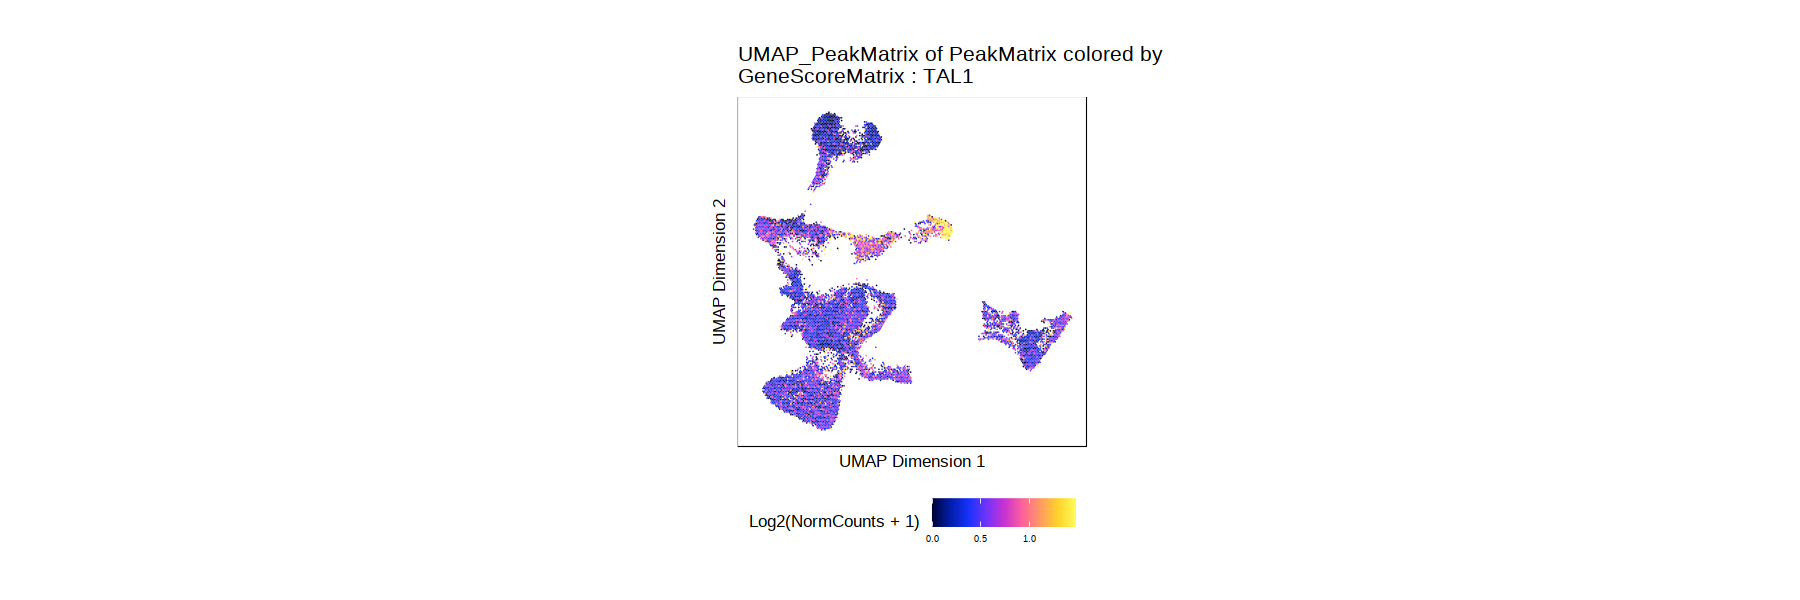

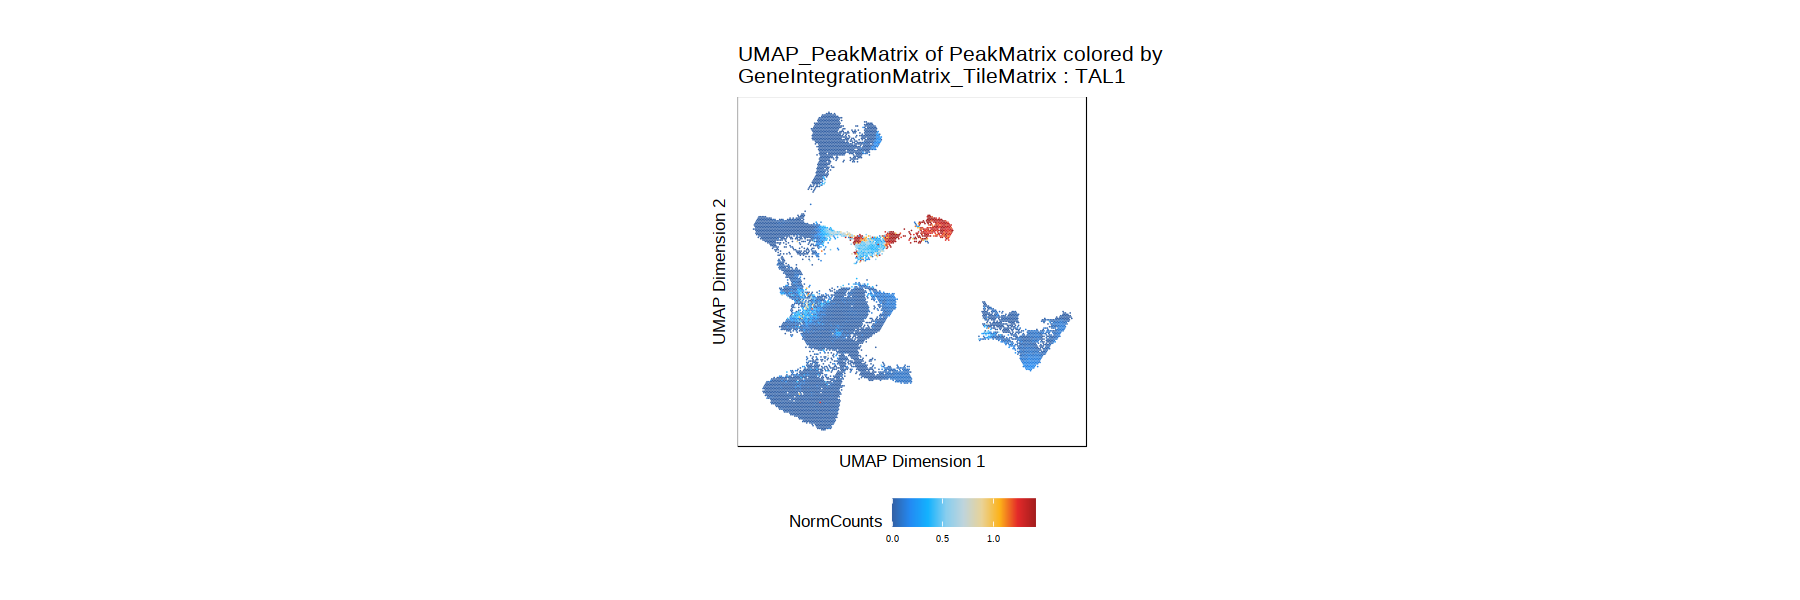

In [8]:
plotEmbedding(
    ArchRProj = ArchRProject, 
  embedding = "UMAP_PeakMatrix",
  colorBy = 'GeneScoreMatrix',
  name = "TAL1")

plotEmbedding(
    ArchRProj = ArchRProject, 
  embedding = "UMAP_PeakMatrix",
  colorBy = 'GeneIntegrationMatrix_TileMatrix',
  name = "TAL1")

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id      symbol
         <Rle>         <IRanges>  <Rle> |        <character> <character>
  [1]    chr19 38829599-38830939      + | ENSOCUG00000001720       HOXB1
  -------
  seqinfo: 22 sequences from an unspecified genome


Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“Removed 30 rows containing missing values (position_stack).”
Picking joint bandwidth of 0.223

Picking joint bandwidth of 0.0116

Picking joint bandwidth of 0.00026

Picking joint bandwidth of 1.15e-06

Picking joint bandwidth of 0.000782

Picking joint bandwidth of 6.45e-05

Picking joint bandwidth of 0.216

Picking joint bandwidth of 0.000937

Picking joint bandwidth of 0.3

Picking joint bandwidth of 0.00582

Picking joint bandwidth of 0.0149

Picking joint bandwidth of 0.00535

Picking joint bandwidth of 0.00534

Picking joint bandwidth of 0.000704

Picking joint bandwidth of 0.015

Picking joint bandwidth of 0.000748

Picking joint bandwidth of 0.0

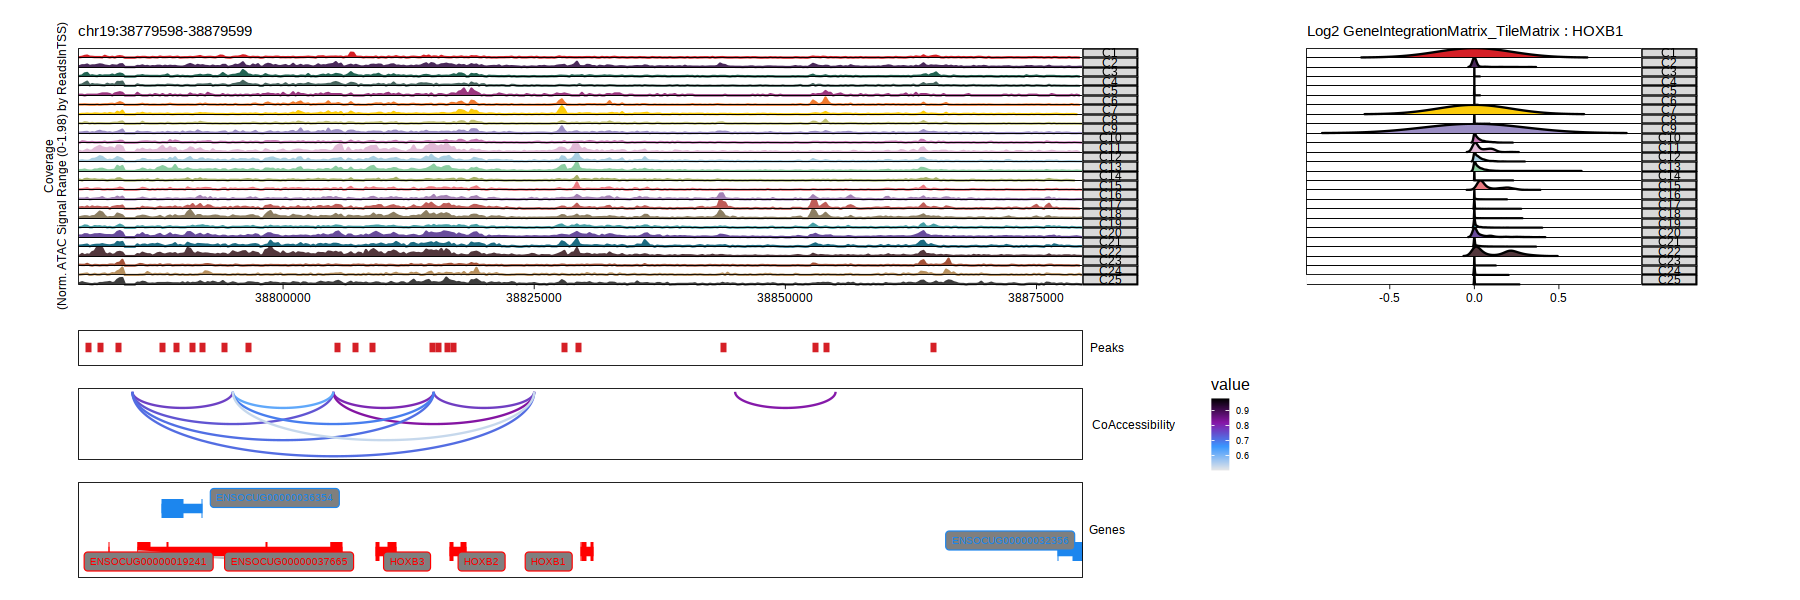

In [7]:
markerGenes = 'HOXB1'

p <- suppressMessages( plotBrowserTrack(
    ArchRProj = ArchRProject, 
    groupBy = "Clusters_PeakMatrix", 
    geneSymbol = markerGenes, 
    upstream = 50000,
    downstream = 50000,
    #loops = getPeak2GeneLinks(ArchRProject, resolution = 1)#,
    useMatrix = "GeneIntegrationMatrix_TileMatrix",
   loops = getCoAccessibility(ArchRProject, resolution = 10000)
))

grid::grid.newpage()
grid::grid.draw(p[[1]])

In [5]:
args = list()
args$matrix = 'PeakMatrix'
args$colour_by = c("sample","stage", "predictedGroup_celltype_TileMatrix", "predictedScore_celltype", "DoubletEnrichment", "nFrags", "Clusters_PeakMatrix", "TSSEnrichment")
args$outdir = file.path(io$basedir, 'ArchR/dimensionality_reduction')
args$nfeatures = 25000
args$ndims = 45
i = 35
j = 0.3

args$colour_by =  "predictedGroup_celltype_PeakMatrix"

# Fetch UMAP coordinates
        umap.dt <- getEmbedding(ArchRProject,paste0("UMAP_", args$matrix)) %>%
          round(2) %>%
          as.data.table(keep.rownames = T) %>%
          setnames(c("cell","umap1","umap2"))

    sample_metadata = as.data.frame(getCellColData(ArchRProject))


# Plot
        to.plot <- umap.dt %>%
          merge(sample_metadata,by="cell")

        for (k in args$colour_by) {

          # log10 large numeric values
          if (is.numeric(to.plot[[k]])) {
            if (max(to.plot[[k]],na.rm=T) - min(to.plot[[k]],na.rm=T) > 1000) {
              to.plot[[k]] <- log10(to.plot[[k]]+1)
              to.plot %>% setnames(k,paste0(k,"_log10")); k <- paste0(k,"_log10")
            }
          }

          p <- ggplot(to.plot, aes_string(x="umap1", y="umap2", fill=k)) +
            geom_point(size=1.5, shape=21, stroke=0.05) +
            theme_void() 

          # Define colormap
          if (is.numeric(to.plot[[k]])) {
            p <- p + scale_fill_gradientn(colours = terrain.colors(10))
          }

#           if (grepl("celltype",k)) {
#             p <- p + scale_fill_manual(values=opts$celltype.colors) +
#               theme(
#                 legend.position="none",
#                 legend.title=element_blank()
#               )
#           }

         if (is.character(to.plot[[k]])) {
                p <- p + scale_fill_manual(values = as.vector(c(ArchRPalettes[[3]],ArchRPalettes[[5]], ArchRPalettes[[8]],ArchRPalettes[[9]]))[1:length(unique(to.plot[[k]]))])
              }
              
          if (grepl("stage",k)) {
            p <- p + scale_fill_manual(values=opts$stage.colors)}
           
           

        outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_nn%s_dist%s_%s.pdf",args$outdir, args$matrix, args$nfeatures, args$ndims,i,j, k)

        if (length(args$batch.variable)>0) {
              outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_nn%s_dist%s_%sbatchcorrection_by_%s_%s.pdf",args$outdir, args$matrix, args$nfeatures,args$ndims,i,j, args$batch.method, paste(args$batch.variable,collapse="-"), k)
            }
          pdf(outfile, width=7, height=5)
          print(p)
          dev.off()
        }
        
      

# RNA

In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE



In [2]:
    io$RNA_in <- file.path(io$basedir,"RNA/RangedSummarizedExperiment.rds")
    sceRNA = readRDS(io$RNA_in)
    

In [3]:
colData(sceRNA)

DataFrame with 146133 rows and 28 columns
               sample       stage     batch doub.density   doublet   cluster
            <integer> <character> <integer>    <numeric> <logical> <numeric>
cell_1              1         GD7         1      6.36720     FALSE         4
cell_2              1         GD7         1      0.00000     FALSE         2
cell_4              1         GD7         1     43.04933     FALSE         4
cell_5              1         GD7         1      8.40279     FALSE        10
cell_6              1         GD7         1     61.32555     FALSE         4
...               ...         ...       ...          ...       ...       ...
cell_172991        26         GD9         1      1.84421     FALSE        13
cell_172992        26         GD9         1      6.67889     FALSE        16
cell_172993        26         GD9         1      2.26659     FALSE        13
cell_172994        26         GD9         1      7.82614     FALSE        16
cell_172995        26         GD9 

In [ ]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))

geneAnnotation = readRDS(file.path(io$basedir, 'geneAnnotation.rds'))

geneAnnotation

rna_in = '/rds/project/rds-SDzz0CATGms/users/mlnt2/PhD_MT06/'
rna_out = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/RNA/'
counts_in = file.path(rna_in, '3_cellqc/raw_counts.mtx')
genes_in = file.path(rna_in, '2_cellcalling/genes.tsv')
meta_in1 = file.path(rna_in, '5_doublet/meta.tab')
meta_in2 = file.path('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/metadata.csv')
sizefactors_in = file.path(rna_in, 'sizefactors.tab')

dir.create(file.path(rna_out), showWarnings = FALSE)


# Load data
counts = readMM(counts_in)
genes = fread(genes_in, header=FALSE)
meta = fread(meta_in1)

# Change col & row names
colnames(counts) = meta$cell
rownames(counts) = genes$V1

# Keep only cells that are not doublet or stripped nuclei
keep = meta[meta$doublet==FALSE & meta$stripped==FALSE,]$cell
counts = counts[,keep]
meta = meta[meta$cell %in% keep,]

# load new metadata
meta = fread(meta_in2)[,-1]
rownames(meta) = meta$cell

# Extract Granges of genes
rowranges = geneAnnotation$genes
genes_keep = genes[genes$V1 %in% rowranges$gene_id,]$V1 # keep only genes in ATAC data
counts = counts[genes_keep, ] 
rowranges = rowranges[rowranges$gene_id %in% rownames(counts),]
rowranges = rowranges[order(match(rowranges$gene_id, rownames(counts))),] # Match order between RNA & ATAC (not needed?)

# Create Ranged SummarizedExperiment object of scRNA-seq data
sceRNA <- SummarizedExperiment(assays=SimpleList(counts=counts),rowRanges=rowranges[,0], colData=meta)
rownames(sceRNA) = sceRNA@rowRanges$symbol

# Save object
saveRDS(sceRNA, file.path(rna_out, 'RangedSummarizedExperiment.rds'))


In [4]:

rna_in = '/rds/project/rds-SDzz0CATGms/users/mlnt2/PhD_MT06/'
rna_out = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/RNA/'
counts_in = file.path(rna_in, '3_cellqc/raw_counts.mtx')
genes_in = file.path(rna_in, '2_cellcalling/genes.tsv')
meta_in1 = file.path(rna_in, '5_doublet/meta.tab')
meta_in2 = file.path('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/metadata.csv')
sizefactors_in = file.path(rna_in, 'sizefactors.tab')

dir.create(file.path(rna_out), showWarnings = FALSE)


# Load data
counts = readMM(counts_in)
genes = fread(genes_in, header=FALSE)
meta = fread(meta_in1)

# Change col & row names
colnames(counts) = meta$cell
rownames(counts) = genes$V1

# Keep only cells that are not doublet or stripped nuclei
keep = meta[meta$doublet==FALSE & meta$stripped==FALSE,]$cell
counts = counts[,keep]


In [26]:
# Extract Granges of genes
rowranges = geneAnnotation$genes
genes_keep = genes[genes$V1 %in% rowranges$gene_id,]$V1 # keep only genes in ATAC data
counts = counts[genes_keep, ] 
rowranges = rowranges[rowranges$gene_id %in% rownames(counts),]
rowranges = rowranges[order(match(rowranges$gene_id, rownames(counts))),] # Match order between RNA & ATAC (not needed?)

In [48]:
celltypes = fread(paste0(rna_out, 'annotations_final.tsv')) %>%
     setnames(c('V1', 'assigned_celltype'), c('cell', 'celltype')) %>%
    .[order(match(cell, colnames(counts))),]
stages = fread(paste0(rna_out, 'metadata.csv')) %>%
    setnames('index', 'cell') %>%
     .[,c('cell', 'stage')] %>%
     .[order(match(cell, colnames(counts))),] 
meta = cbind(celltypes, stages[,2])

Warning message in fread(paste0(rna_out, "annotations_final.tsv")):
“Detected 1 column names but the data has 2 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


In [51]:
# Create Ranged SummarizedExperiment object of scRNA-seq data
sceRNA <- SummarizedExperiment(assays=SimpleList(counts=counts),rowRanges=rowranges, colData=meta)
rownames(sceRNA) = sceRNA@rowRanges$symbol

In [53]:
# Save object
saveRDS(sceRNA, file.path(rna_out, 'RangedSummarizedExperiment.rds'))
